# Integrantes
*   Johel Santiago Arias Becerra
*   Rebeca Pedrozo Cueto
*   Carlos Fernando Aragon
*   Juan Pablo Marquez Alfonso

In [ ]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# 1. Limpieza de datos

### Cargar el Dataframe en Colab
Durante este paso se realiza el cargue del dataset de wage11 bajo el nombre de data_source

In [ ]:
from google.colab import files
uploaded = files.upload()

### Cargar el dataset en memoria
Posteriomente se carga el dataframe en memoria, leyendo el archivo excel

In [ ]:
df = pd.read_excel("data_source.xlsx")

df.head()

,id,wage,CAT,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs
0,1,1710.0,ALTO,45,118.0,40,18.0,12.0,12,38.0,1,0.0,0,1,1.0
1,2,1025.0,MEDIO,40,110.0,30,16.0,9.0,4,30.0,1,0.0,0,0,3.0
2,3,821.0,MEDIO,45,85.0,39,16.0,8.0,2,32.0,1,0.0,0,1,5.0
3,4,1111.0,MEDIO,45,NaN,43,15.0,11.0,3,32.0,1,0.0,0,1,3.0
4,5,1261.0,MEDIO,40,117.0,41,17.0,1.0,9,35.0,1,0.0,0,1,4.0


### Inspección estructural inicial.
Se realiza una inspeccion de tipos en los datos, junto al resumen estadistico del dataframe.

In [ ]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
id           int64
wage       float64
CAT         object
hours        int64
IQ         float64
KWW          int64
educ       float64
exper      float64
tenure       int64
age        float64
married      int64
black      float64
south        int64
urban        int64
sibs       float64
dtype: object


En esta tabla podemos observar todos los valores de la estadistica descriptiva, resaltando principalmente la media y mediana.

Al utilizar el dataset sin limpieza, se puede observar un sesgo a la derecha, ya que en gran parte de las columnas, los valores de la media son mayores a los de la mediana

In [ ]:
print("\nResumen estadístico:")
df.describe(include='all')


Resumen estadístico:


,id,wage,CAT,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs
count,935.00000,871.000000,935,935.000000,907.000000,935.000000,890.000000,914.000000,935.000000,900.000000,935.000000,899.000000,935.000000,935.000000,918.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,MEDIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,468.00000,981.739380,NaN,44.327273,101.001103,35.224599,13.424719,11.277899,6.781818,33.031111,0.897326,0.120133,0.321925,0.737968,3.081699
std,270.05555,442.978897,NaN,7.126860,14.304671,7.561796,2.105608,4.385755,5.109873,2.994457,0.303695,0.325299,0.467464,0.439975,2.278072
min,1.00000,115.000000,NaN,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,234.50000,699.000000,NaN,40.000000,93.000000,29.000000,12.000000,8.000000,2.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,468.00000,904.000000,NaN,40.000000,100.000000,36.000000,13.000000,11.000000,6.000000,33.000000,1.000000,0.000000,0.000000,1.000000,3.000000
75%,701.50000,1161.500000,NaN,50.000000,110.000000,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,5.000000


### Normalización de nombres de columnas
En este paso, realizamos una normalizacion a los nombres de las columnas, con el fin de utilizar nombres mas descriptivos de acuerdo al dato que estan proporcionando

In [ ]:
df.columns = df.columns.str.strip().str.lower()

df.rename(columns={
    'wage': 'salario',
    'cat': 'categoria',
    'hours': 'horas_laborales',
    'iq': 'iq',
    'kww': 'capital_trabajo_score',
    'educ': 'anios_educacion',
    'exper': 'anios_experiencia',
    'tenure': 'tiempo_cargo_actual',
    'age': 'edad',
    'married': 'casado',
    'black': 'raza_negra',
    'south': 'vive_sur',
    'urban': 'zona_urbana',
    'sibs': 'numero_hermanos'
}, inplace=True)

df.head()

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
0,1,1710.0,ALTO,45,118.0,40,18.0,12.0,12,38.0,1,0.0,0,1,1.0
1,2,1025.0,MEDIO,40,110.0,30,16.0,9.0,4,30.0,1,0.0,0,0,3.0
2,3,821.0,MEDIO,45,85.0,39,16.0,8.0,2,32.0,1,0.0,0,1,5.0
3,4,1111.0,MEDIO,45,NaN,43,15.0,11.0,3,32.0,1,0.0,0,1,3.0
4,5,1261.0,MEDIO,40,117.0,41,17.0,1.0,9,35.0,1,0.0,0,1,4.0


### Eliminacion de Duplicados

#### Eliminación de duplicados por id.

Primero se realiza una busqueda de duplicados a traves del subset definido. Cuyo unico valor esta dado por el id.

In [ ]:
duplicados_totales = df.duplicated(subset=['id']).sum()
print("Duplicados encontrados:", duplicados_totales)

df_cleaned = df.drop_duplicates(subset=['id'])
df_cleaned.describe()

Duplicados encontrados: 0


,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,935.00000,871.000000,935.000000,907.000000,935.000000,890.000000,914.000000,935.000000,900.000000,935.000000,899.000000,935.000000,935.000000,918.000000
mean,468.00000,981.739380,44.327273,101.001103,35.224599,13.424719,11.277899,6.781818,33.031111,0.897326,0.120133,0.321925,0.737968,3.081699
std,270.05555,442.978897,7.126860,14.304671,7.561796,2.105608,4.385755,5.109873,2.994457,0.303695,0.325299,0.467464,0.439975,2.278072
min,1.00000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,234.50000,699.000000,40.000000,93.000000,29.000000,12.000000,8.000000,2.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,468.00000,904.000000,40.000000,100.000000,36.000000,13.000000,11.000000,6.000000,33.000000,1.000000,0.000000,0.000000,1.000000,3.000000
75%,701.50000,1161.500000,50.000000,110.000000,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,5.000000
max,935.00000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


### Eliminacion de duplicados por estructura
Posteriomente se realiza una busqueda por el resto de valores del dataframe. Donde se comparan todas las columnas a excepcion del id, para la identificacion de duplicados estructurales (Donde todos los valores son exactamente iguales)

In [ ]:
index = [
  'salario',
  'categoria',
  'horas_laborales',
  'iq',
  'capital_trabajo_score',
  'anios_educacion',
  'anios_experiencia',
  'tiempo_cargo_actual',
  'edad',
  'casado',
  'raza_negra',
  'vive_sur',
  'zona_urbana',
  'numero_hermanos'
]

duplicados_estructura = df_cleaned.duplicated(
  subset=index
).sum()

print("Duplicados por estructura:", duplicados_estructura)

df_cleaned = df_cleaned.drop_duplicates(subset=index)
df_cleaned.describe()

Duplicados por estructura: 65


,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,870.000000,806.000000,870.000000,842.000000,870.000000,825.000000,849.000000,870.000000,835.000000,870.000000,834.000000,870.000000,870.000000,854.000000
mean,470.560920,988.008685,43.903448,101.232779,35.689655,13.458182,11.605418,7.213793,33.033533,0.889655,0.129496,0.345977,0.718391,2.937939
std,271.006674,459.943101,7.211413,14.821907,7.638270,2.183568,4.381675,5.037516,3.108945,0.313499,0.335950,0.475959,0.450043,2.298302
min,1.000000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,238.250000,675.000000,40.000000,92.000000,31.000000,12.000000,8.000000,3.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,467.500000,909.500000,40.000000,102.000000,37.000000,12.000000,11.000000,7.000000,33.000000,1.000000,0.000000,0.000000,1.000000,2.000000
75%,708.750000,1200.000000,47.000000,111.000000,41.000000,16.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,4.000000
max,935.000000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


### Eliminacion de duplicados por variables significativas
Al realizar la eliminacion de duplicados por estructura, se realiza la eliminacion de duplicados por variables significativas.

En este caso seleccionamos unicamente variables demograficas de las personas registradas. Por lo tanto la eliminacion eta orientada unicamente a la busqueda de registros duplicados de una misma persona

In [ ]:
index = [
        'categoria',
        'iq',
        'anios_educacion',
        'anios_experiencia',
        'edad',
        'casado',
        'raza_negra',
        'vive_sur',
        'zona_urbana',
        'numero_hermanos'
      ]
duplicados_significativos = df_cleaned.duplicated(
    subset=index
  ).sum()

print("Duplicados por variables significativas:", duplicados_significativos)

df_cleaned = df_cleaned.drop_duplicates(subset=index)
df_cleaned.describe()

Duplicados por variables significativas: 2


,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,868.000000,804.000000,868.000000,840.000000,868.000000,823.000000,847.000000,868.000000,833.000000,868.000000,832.000000,868.000000,868.000000,852.000000
mean,470.525346,987.930348,43.891705,101.244048,35.695853,13.461725,11.608028,7.218894,33.043217,0.889401,0.129808,0.345622,0.718894,2.941315
std,271.041488,460.493528,7.211568,14.837739,7.640548,2.185037,4.386454,5.041970,3.106376,0.313816,0.336294,0.475845,0.449798,2.299815
min,1.000000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,238.750000,674.500000,40.000000,92.000000,31.000000,12.000000,8.000000,3.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,467.500000,909.000000,40.000000,102.000000,37.000000,12.000000,11.000000,7.000000,33.000000,1.000000,0.000000,0.000000,1.000000,2.000000
75%,708.250000,1200.000000,47.000000,111.000000,41.000000,16.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,4.000000
max,935.000000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


### Detección de valores faltantes
Ahora que ya se realizo la eliminacion de valores duplicados, se identifican los valores faltantes de cada una de las columnas del dataframe.

Para ello se crea un nuevo dataframe que contiene la informacion del total de valores nulos y el porcetaje que representa para cada una de las columnas

In [ ]:
valores_nulos = df_cleaned.isnull().sum()
porcentaje_nulos = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

tabla_nulos = pd.DataFrame({
    'cantidad_nulos': valores_nulos,
    'porcentaje_%': porcentaje_nulos
})

tabla_nulos.sort_values(by='cantidad_nulos', ascending=False)

,cantidad_nulos,porcentaje_%
salario,64,7.373272
anios_educacion,45,5.184332
raza_negra,36,4.147465
edad,35,4.032258
iq,28,3.225806
anios_experiencia,21,2.419355
numero_hermanos,16,1.843318
capital_trabajo_score,0,0.000000
horas_laborales,0,0.000000
id,0,0.000000


## Completar valores faltantes
Conociendo cuales columnas son las que presentan valores faltantes, es posible completarlos a traves de la media, mediana, moda o a traves de una regresion


A continuacion se define una funcion que permita extraer las columnas numericas de un dataframe, con el fin de reutilizarla en la completitud de datos faltantes.

Se extraen unicamente las columnas con tipo numerico, ya que para realizar el calculo de las medidas estadisticas, como la media y mediana son necesarios unicamente valores numericos

In [ ]:
def get_columns(df):
  columns = df.select_dtypes(include=np.number).columns
  return columns

### Uso de la Media para completar valores faltantes
Para este primer caso, se completan los valores faltantes a traves del uso de la media calculada de cada fila


In [ ]:
df_media = df_cleaned.copy()

columns = get_columns(df_media)

for col in columns:
  media = df_media[col].mean()
  df_media[col].fillna(media, inplace=True)

df_media.isnull().sum()

/tmp/ipython-input-807/2469201222.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_media[col].fillna(media, inplace=True)


,0
id,0
salario,0
categoria,0
horas_laborales,0
iq,0
capital_trabajo_score,0
anios_educacion,0
anios_experiencia,0
tiempo_cargo_actual,0
edad,0


In [ ]:
df_media.describe()

,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000
mean,470.525346,987.930348,43.891705,101.244048,35.695853,13.461725,11.608028,7.218894,33.043217,0.889401,0.129808,0.345622,0.718894,2.941315
std,271.041488,443.171429,7.211568,14.596178,7.640548,2.127576,4.333005,5.041970,3.043029,0.313816,0.329238,0.475845,0.449798,2.278495
min,1.000000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,238.750000,696.750000,40.000000,93.000000,31.000000,12.000000,8.000000,3.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,467.500000,951.500000,40.000000,101.244048,37.000000,13.000000,11.000000,7.000000,33.000000,1.000000,0.000000,0.000000,1.000000,2.000000
75%,708.250000,1162.000000,47.000000,111.000000,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,4.000000
max,935.000000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


### Uso de la Mediana para completar valores faltantes
Luego se realiza el calculo de la mediana para cada fila


In [ ]:
df_mediana = df_cleaned.copy()

columns = get_columns(df_mediana)

for col in columns:
  mediana = df_media[col].median()
  df_mediana[col].fillna(mediana, inplace=True)

df_mediana.isnull().sum()

/tmp/ipython-input-807/2313272940.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mediana[col].fillna(mediana, inplace=True)


,0
id,0
salario,0
categoria,0
horas_laborales,0
iq,0
capital_trabajo_score,0
anios_educacion,0
anios_experiencia,0
tiempo_cargo_actual,0
edad,0


In [ ]:
df_mediana.describe()

,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000
mean,470.525346,985.244240,43.891705,101.244048,35.695853,13.437788,11.593318,7.218894,33.041475,0.889401,0.124424,0.345622,0.718894,2.923963
std,271.041488,443.273799,7.211568,14.596178,7.640548,2.130040,4.334013,5.041970,3.043041,0.313816,0.330255,0.475845,0.449798,2.282015
min,1.000000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,238.750000,696.750000,40.000000,93.000000,31.000000,12.000000,8.000000,3.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,467.500000,951.250000,40.000000,101.244048,37.000000,13.000000,11.000000,7.000000,33.000000,1.000000,0.000000,0.000000,1.000000,2.000000
75%,708.250000,1162.000000,47.000000,111.000000,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,4.000000
max,935.000000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


### Uso de la Moda para completar valores faltantes
Luego se realiza el calculo a traves de la moda, donde para este caso en especifico, ya no es necesario el uso exclusivo de columnas con tipos numericos. Por lo tanto se utilizan todas las columnas del dataframe


In [ ]:
df_moda = df.copy()

for col in df_moda.columns:

  existe_moda = df_moda[col].mode().size > 0

  if not existe_moda:
    continue

  moda = df_moda[col].mode()[0]  # Se toma la moda principal
  df_moda[col].fillna(moda, inplace=True)

df_moda.isnull().sum()

/tmp/ipython-input-807/2028793497.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_moda[col].fillna(moda, inplace=True)
/tmp/ipython-input-807/2028793497.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
id,0
salario,0
categoria,0
horas_laborales,0
iq,0
capital_trabajo_score,0
anios_educacion,0
anios_experiencia,0
tiempo_cargo_actual,0
edad,0


In [ ]:
df_moda.describe()

,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,935.00000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000
mean,468.00000,976.418182,44.327273,100.911230,35.224599,13.356150,11.181818,6.781818,33.029947,0.897326,0.115508,0.321925,0.737968,3.043850
std,270.05555,427.983504,7.126860,14.097915,7.561796,2.076792,4.382305,5.109873,2.937821,0.303695,0.319805,0.467464,0.439975,2.274334
min,1.00000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,234.50000,720.500000,40.000000,94.000000,29.000000,12.000000,7.000000,2.000000,31.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,468.00000,904.000000,40.000000,100.000000,36.000000,12.000000,11.000000,6.000000,33.000000,1.000000,0.000000,0.000000,1.000000,3.000000
75%,701.50000,1141.500000,50.000000,110.000000,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,5.000000
max,935.00000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


## Uso de Regresion para completar valores faltantes
Finalmente, se realiza el calculo de los valores faltantes a traves de una regresion para cada columna con al menos un valor faltante dentro de todas sus filas

Para ello, definimos una funcion que recibe dos dataframes a traves de los parametros.

*   df_cleaned => Dataframe a procesar
*   columnas_con_nulos => Dataframe creando anteriormente que contiene el numero de valores nulos por cada columna

Y por cada una de estas columnas, se completan los datos faltantes a traves del calculo por regresion




In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

columnas_enteras = [
    'edad', 'anios_educacion', 'anios_experiencia',
    'tiempo_cargo_actual', 'numero_hermanos', 'id', 'horas_laborales'
]

columnas_booleanas = ['casado', 'raza_negra', 'vive_sur', 'zona_urbana']

def imputacion_por_regresion(df_cleaned, columnas_con_nulos):
  print(columnas_con_nulos)

  df_reg = df_cleaned.copy()

  for columna_objetivo in columnas_con_nulos:
    print(f"Completando columna: {columna_objetivo}")

    df_objetivo = df_reg[columna_objetivo]

    # Separar datos completos y faltantes
    df_train = df_reg[df_objetivo.notnull()]
    df_missing = df_reg[df_objetivo.isnull()]


    # Variables predictoras (solo numéricas y sin la columna objetivo)
    X_train = df_train.select_dtypes(include=np.number).drop(columns=[columna_objetivo])
    y_train = df_train[columna_objetivo]

    # Asegurar que no existan nulos en X_train
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index]


    # Modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Preparar datos faltantes
    X_missing = df_missing.select_dtypes(include=np.number).drop(columns=[columna_objetivo])

    # Eliminar filas con nulos en predictores
    X_missing = X_missing.dropna()

    if columna_objetivo in columnas_booleanas:

        modelo = LogisticRegression(max_iter=1000)
        modelo.fit(X_train, y_train.astype(int))

        probabilidades = modelo.predict_proba(X_missing)[:, 1]
        predicciones = (probabilidades >= 0.5).astype(int)
        predicciones = predicciones

    else:

        modelo = LinearRegression()
        modelo.fit(X_train, y_train)

        predicciones = modelo.predict(X_missing)

        # Si es entera → redondear
        if columna_objetivo in columnas_enteras:
            predicciones = np.round(predicciones)
            predicciones = np.where(predicciones < 0, 0, predicciones)
            predicciones = predicciones.astype(int)

    df_reg.loc[X_missing.index, columna_objetivo] = predicciones

    print(f"{len(predicciones)} valores completados en {columna_objetivo}")

    print(f"{len(predicciones)} valores completados en la columna {columna_objetivo}")

  return df_reg

Y se realiza el calculo llamando a la funcion anterior enviando los parametros correspondientes. En este caso las columnas con nulos y el df_cleaned

In [ ]:
columnas_con_nulos = tabla_nulos[tabla_nulos["cantidad_nulos"] > 0].index.tolist()

df_regresion = imputacion_por_regresion(df_cleaned, columnas_con_nulos)

# Verificación final
df_regresion.isnull().sum()

['salario', 'iq', 'anios_educacion', 'anios_experiencia', 'edad', 'raza_negra', 'numero_hermanos']
Completando columna: salario
64 valores completados en salario
64 valores completados en la columna salario
Completando columna: iq
28 valores completados en iq
28 valores completados en la columna iq
Completando columna: anios_educacion
45 valores completados en anios_educacion
45 valores completados en la columna anios_educacion
Completando columna: anios_experiencia
21 valores completados en anios_experiencia
21 valores completados en la columna anios_experiencia
Completando columna: edad
35 valores completados en edad
35 valores completados en la columna edad
Completando columna: raza_negra
36 valores completados en raza_negra
36 valores completados en la columna raza_negra
Completando columna: numero_hermanos
16 valores completados en numero_hermanos
16 valores completados en la columna numero_hermanos


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,0
id,0
salario,0
categoria,0
horas_laborales,0
iq,0
capital_trabajo_score,0
anios_educacion,0
anios_experiencia,0
tiempo_cargo_actual,0
edad,0


In [ ]:
df_regresion.describe()

,id,salario,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
count,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000,868.000000
mean,470.525346,991.462880,43.891705,101.282224,35.695853,13.461982,11.585253,7.218894,33.066820,0.889401,0.127880,0.345622,0.718894,2.940092
std,271.041488,446.279078,7.211568,14.763025,7.640548,2.146789,4.355682,5.041970,3.074643,0.313816,0.334149,0.475845,0.449798,2.280979
min,1.000000,115.000000,20.000000,50.000000,12.000000,9.000000,1.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,238.750000,692.750000,40.000000,92.000000,31.000000,12.000000,8.000000,3.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,467.500000,929.500000,40.000000,102.000000,37.000000,12.000000,11.000000,7.000000,33.000000,1.000000,0.000000,0.000000,1.000000,2.000000
75%,708.250000,1199.250000,47.000000,111.628457,41.000000,15.000000,15.000000,11.000000,36.000000,1.000000,0.000000,1.000000,1.000000,4.000000
max,935.000000,3462.000000,80.000000,145.000000,56.000000,18.000000,23.000000,22.000000,38.000000,1.000000,1.000000,1.000000,1.000000,14.000000


## Comparativa

Tras realizar todos los calculos correspondientes a completar los valores faltantes, definimos una funcion para comparar los valores estadisticos de cada uno de los dataframes creados.

Donde por cada valor de los dataframes, se puede observar

1.   Nombre del DF al que pertenece
2.   Nombre de la variable/columna
3.   Valor de la media
4.   Valor de la mediana
5.   Valor de desviacion estandar
6.   Valor de la varianza


In [ ]:
def comparar_estadisticas(df_original, df_media, df_mediana, df_moda, df_regresion):

  datasets = {
    "DF Original": df_original,
    "DF Media": df_media,
    "DF Mediana": df_mediana,
    "DF Moda": df_moda,
    "DF Regresion": df_regresion
  }

  resultados = []

  for nombre, dataset in datasets.items():

    df_num = dataset.select_dtypes(include=np.number)

    resumen = pd.DataFrame({
      "Nombre del Dataset": nombre,
      "Variable": df_num.columns,
      "Media": df_num.mean().values,
      "Mediana": df_num.median().values,
      "Desv_Estandar": df_num.std().values,
      "Varianza": df_num.var().values
    })

    resultados.append(resumen)

  comparacion_final = pd.concat(resultados, ignore_index=True)

  return comparacion_final

tabla_comparativa = comparar_estadisticas(
  df_cleaned,
  df_media,
  df_mediana,
  df_moda,
  df_regresion
)

tabla_comparativa.sort_values(["Variable", "Nombre del Dataset"])

,Nombre del Dataset,Variable,Media,Mediana,Desv_Estandar,Varianza
19,DF Media,anios_educacion,13.461725,13.0,2.127576,4.526579
33,DF Mediana,anios_educacion,13.437788,13.0,2.130040,4.537071
47,DF Moda,anios_educacion,13.356150,12.0,2.076792,4.313064
5,DF Original,anios_educacion,13.461725,12.0,2.185037,4.774385
61,DF Regresion,anios_educacion,13.461982,12.0,2.146789,4.608703
...,...,...,...,...,...,...
26,DF Media,zona_urbana,0.718894,1.0,0.449798,0.202318
40,DF Mediana,zona_urbana,0.718894,1.0,0.449798,0.202318
54,DF Moda,zona_urbana,0.737968,1.0,0.439975,0.193578
12,DF Original,zona_urbana,0.718894,1.0,0.449798,0.202318


Con esto dicho, el dataframe resultante y con valores mas adecuados para el resto del procesamiento, es el dataframe df_regresion, debido a que el calculo de valores faltantes, esta dado por la correlacion de variables, lo que permite obtener valores coherentes segun el comportamiento de cada fila

In [ ]:
df_regresion.head()

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
0,1,1710.0,ALTO,45,118.000000,40,18.0,12.0,12,38.0,1,0.0,0,1,1.0
1,2,1025.0,MEDIO,40,110.000000,30,16.0,9.0,4,30.0,1,0.0,0,0,3.0
2,3,821.0,MEDIO,45,85.000000,39,16.0,8.0,2,32.0,1,0.0,0,1,5.0
3,4,1111.0,MEDIO,45,112.466024,43,15.0,11.0,3,32.0,1,0.0,0,1,3.0
4,5,1261.0,MEDIO,40,117.000000,41,17.0,1.0,9,35.0,1,0.0,0,1,4.0


## Validación de Formatos y Consistencia
Posteriormente al calculo de valores faltantes, se realiza la validacion de formatos y consistencia de cada una de las columnas de dataframe.

Donde se realizan validaciones de columnas mayores a 0, columnas booleanas y columnas dadas por enumeradores (Como la columna de categoria)

In [ ]:
def validar_y_normalizar(df):

  df_clean = df.copy()
  inconsistencias = {}


  columnas_mayor_0 = [
    'id', 'salario', 'horas_laborales', 'iq',
    'capital_trabajo_score', 'anios_educacion',
    'anios_experiencia', 'tiempo_cargo_actual', 'edad'
  ]


  for col in columnas_mayor_0:
    if col in df_clean.columns:

      df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

      df_clean[col] = df_clean[col].fillna(0)

      invalidos = df_clean[df_clean[col] < 0]
      inconsistencias[col] = len(invalidos)


  if 'numero_hermanos' in df_clean.columns:
    df_clean['numero_hermanos'] = pd.to_numeric(df_clean['numero_hermanos'], errors='coerce')
    df_clean['numero_hermanos'] = df_clean['numero_hermanos'].fillna(0)
    invalidos = df_clean[df_clean['numero_hermanos'] < 0]
    inconsistencias['numero_hermanos'] = len(invalidos)


  columnas_booleanas = ['casado', 'raza_negra', 'vive_sur', 'zona_urbana']


  for col in columnas_booleanas:
    if col in df_clean.columns:

      df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

      df_clean[col] = df_clean[col].fillna(0)

      invalidos = df_clean[~df_clean[col].isin([0, 1])]
      inconsistencias[col] = len(invalidos)

      df_clean[col] = df_clean[col].apply(lambda x: 1 if x == 1 else 0)

      df_clean[col] = df_clean[col].astype(bool)

  if 'categoria' in df_clean.columns:
    categorias_validas = ['ALTO', 'MEDIO', 'BAJO']
    invalidos = df_clean[~df_clean['categoria'].isin(categorias_validas)]
    inconsistencias['categoria'] = len(invalidos)


  reporte = pd.DataFrame({
    "Variable": inconsistencias.keys(),
    "Registros_Invalidos": inconsistencias.values()
  }).sort_values("Registros_Invalidos", ascending=False)

  return df_clean, reporte


df_validado, reporte_validacion = validar_y_normalizar(df_regresion)

df_limpio = df_validado.copy()

reporte_validacion

,Variable,Registros_Invalidos
0,id,0
1,salario,0
2,horas_laborales,0
3,iq,0
4,capital_trabajo_score,0
5,anios_educacion,0
6,anios_experiencia,0
7,tiempo_cargo_actual,0
8,edad,0
9,numero_hermanos,0


Finalmente, el dataframe df_limpio, ya cuenta con todo el proceso de limpieza de datos.

Donde se le realizo la limpieza de datos por id, estructura y variables significativas.
Se le realizo un manejo adecuado de valores de datos faltantes a traves de regresion y finalmente validacion de formatos y consistencia de variables

In [ ]:
df_limpio.sample(10)

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos
479,480,403.000000,BAJO,45,98.000000,37,12.0,5.0,3,30.0,True,False,True,True,2.0
512,513,1058.000000,MEDIO,40,94.000000,40,14.0,13.0,14,34.0,True,False,False,True,0.0
506,507,1282.000000,MEDIO,60,96.000000,24,18.0,7.0,5,32.0,True,False,True,True,4.0
745,746,1173.825690,BAJO,42,101.000000,34,16.0,12.0,9,31.0,True,False,True,True,0.0
772,773,954.726631,BAJO,40,116.000000,42,15.0,11.0,12,34.0,False,False,False,False,2.0
403,404,562.000000,BAJO,40,99.000000,25,12.0,18.0,12,34.0,False,False,False,False,1.0
478,479,1710.000000,ALTO,45,114.000000,39,18.0,7.0,6,32.0,True,False,False,True,1.0
716,717,540.000000,BAJO,40,77.816319,25,10.0,12.0,10,29.0,True,True,True,False,9.0
543,544,700.000000,MEDIO,40,74.000000,29,12.0,16.0,4,36.0,True,True,True,True,3.0
746,747,1198.000000,MEDIO,32,117.000000,39,16.0,7.0,9,30.0,True,False,True,True,1.0


# 2. Estandarización

## Normalizacion del salario

Podemos ver que el salario tiene una dispersión amplia y probablemente valores extremos, hemos normalizado con Min-Max para estandarizar su rango sin alterar su distribución relativa, cuando aplicamos la normalización por Min-Max  llevamos la variable salario a un rango entre 0 y 1.

Habiendo dicho esto, en el seguiente bloque de codigo vamos a encontrar los limites; Maximos y minimos. Posteriormente, aplicamos la respectiva transformación.

In [ ]:
SalarioMinimo = df_limpio['salario'].min()
SalarioMaximo = df_limpio['salario'].max()

print("Salario minimo: ", SalarioMinimo)
print("Salario maximo: ", SalarioMaximo)

Salario minimo:  115.0
Salario maximo:  3462.0


In [ ]:
df_limpio['salario_normalizado'] = (
    (df_limpio['salario'] - SalarioMinimo) /
    (SalarioMaximo - SalarioMinimo)
)

df_limpio[['salario', 'salario_normalizado']].head()

,salario,salario_normalizado
0,1710.0,0.476546
1,1025.0,0.271885
2,821.0,0.210935
3,1111.0,0.297580
4,1261.0,0.342396


Comprobamos de los que valores hayan quedado entre 0 y 1

In [ ]:
print("Mínimo normalizado:", df_limpio['salario_normalizado'].min())
print("Máximo normalizado:", df_limpio['salario_normalizado'].max())

Mínimo normalizado: 0.0
Máximo normalizado: 1.0


## Escalamiento Uniforme de la variable KWW

Se aplicó estandarización manual tipo Z-score a la variable capital_trabajo_score, asi calculamos la media y la desviación estándar, y posteriormente se transformó cada observación restando la media y dividiendo por la desviación estándar

Esto permite centrar la variable en media cero y desviación estándar uno, asi mediremos  la dispersión de los datos respecto a la media, es decir, cuánto se alejan en promedio las observaciones del valor central

In [ ]:
MediaKKW = df_limpio['capital_trabajo_score'].mean()
DesvKKWW = df_limpio['capital_trabajo_score'].std(ddof=0)

df_limpio['KWW_Escalado'] = (
    (df_limpio['capital_trabajo_score'] - MediaKKW) /
    DesvKKWW
)

print("Media escalada:", df_limpio['KWW_Escalado'].mean())
print("Desviación estándar escalada:", df_limpio['KWW_Escalado'].std(ddof=0))

Media escalada: -2.0669589951546692e-16
Desviación estándar escalada: 0.9999999999999996


Aqui vamos a hacer el mismo procedimiento pero aplicando la estandarización de  la clase StandardScaler de sklearn para comprobar, la cual calcula automáticamente la media y la desviación estándar poblacional y transforma la variable para que tenga media cero y desviación estándar uno

In [ ]:
scaler_std = StandardScaler()

df_limpio['KWW_Escalado_skl'] = scaler_std.fit_transform(
    df_limpio[['capital_trabajo_score']]
)

print("Media (sklearn):", df_limpio['KWW_Escalado_skl'].mean())
print("Desviación estándar (sklearn):", df_limpio['KWW_Escalado_skl'].std(ddof=0))

Media (sklearn): -2.0669589951546692e-16
Desviación estándar (sklearn): 0.9999999999999993


In [ ]:
df_limpio.head()

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos,salario_normalizado,KWW_Escalado,KWW_Escalado_skl
0,1,1710.0,ALTO,45,118.000000,40,18.0,12.0,12,38.0,True,False,False,True,1.0,0.476546,0.563654,0.563654
1,2,1025.0,MEDIO,40,110.000000,30,16.0,9.0,4,30.0,True,False,False,False,3.0,0.271885,-0.745907,-0.745907
2,3,821.0,MEDIO,45,85.000000,39,16.0,8.0,2,32.0,True,False,False,True,5.0,0.210935,0.432698,0.432698
3,4,1111.0,MEDIO,45,112.466024,43,15.0,11.0,3,32.0,True,False,False,True,3.0,0.297580,0.956523,0.956523
4,5,1261.0,MEDIO,40,117.000000,41,17.0,1.0,9,35.0,True,False,False,True,4.0,0.342396,0.694611,0.694611


La media y la desviación estándar que nos resultaron son prácticamente 0 y 1 respectivamente. Podemos notar unas  pequeñas diferencias, las cuales las podemos atribuir a la precisión numérica de los flotantes. Gracias a esto, hemos eliminado el efecto de escala original de la variable

In [ ]:
df_limpio.drop(columns=['KWW_Escalado'], inplace=True)

In [ ]:
df_limpio.head()

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos,salario_normalizado,KWW_Escalado_skl
0,1,1710.0,ALTO,45,118.000000,40,18.0,12.0,12,38.0,True,False,False,True,1.0,0.476546,0.563654
1,2,1025.0,MEDIO,40,110.000000,30,16.0,9.0,4,30.0,True,False,False,False,3.0,0.271885,-0.745907
2,3,821.0,MEDIO,45,85.000000,39,16.0,8.0,2,32.0,True,False,False,True,5.0,0.210935,0.432698
3,4,1111.0,MEDIO,45,112.466024,43,15.0,11.0,3,32.0,True,False,False,True,3.0,0.297580,0.956523
4,5,1261.0,MEDIO,40,117.000000,41,17.0,1.0,9,35.0,True,False,False,True,4.0,0.342396,0.694611


# 3. Ingeniería de Características

##Capital Humano

En la etapa de ingeniería de características se creó la variable capital_humano multiplicando anios_educacion por capital_trabajo_score dentro del dataframe df_limpio. Esta transformación permitió integrar en un solo indicador tanto el nivel educativo como las habilidades del individuo, con el fin de obtener una variable más representativa y con mayor capacidad explicativa para futuros análisis o modelos predictivos.


In [ ]:
# Nueva variable: Capital Humano
df_limpio['capital_humano'] = (
    df_limpio['anios_educacion'] *
    df_limpio['capital_trabajo_score']
)

df_limpio[['anios_educacion', 'capital_trabajo_score', 'capital_humano']].head()

,anios_educacion,capital_trabajo_score,capital_humano
0,18.0,40,720.0
1,16.0,30,480.0
2,16.0,39,624.0
3,15.0,43,645.0
4,17.0,41,697.0


### Justificación Capital Humano


La variable capital_humano se creó multiplicando los años de educación (anios_educacion) por el puntaje de capital de trabajo (capital_trabajo_score). Con esto se busca representar de forma más completa el perfil de cada persona, considerando tanto su nivel de estudios como sus habilidades. La idea es que una persona con más educación y mejores capacidades puede tener un mejor desempeño laboral y mayores oportunidades salariales. Por eso, al combinar estas dos variables en una sola, se obtiene una medida más útil para analizar los factores que pueden influir en el salario dentro del dataset.

## Experiencia Total

La variable experiencia_total se crea sumando los años de experiencia laboral general con el tiempo que la persona lleva en su cargo actual. Esta variable permite tener una medida más completa del recorrido laboral del individuo, ya que combina tanto la experiencia acumulada como la estabilidad en su puesto actual.

In [ ]:
df_limpio['experiencia_total'] = (
    df_limpio['anios_experiencia'] +
    df_limpio['tiempo_cargo_actual']
)

df_limpio[['anios_experiencia', 'tiempo_cargo_actual', 'experiencia_total']].head()

,anios_experiencia,tiempo_cargo_actual,experiencia_total
0,12.0,12,24.0
1,9.0,4,13.0
2,8.0,2,10.0
3,11.0,3,14.0
4,1.0,9,10.0


###Justificación Experiencia Total

Esta variable es útil porque la experiencia laboral total puede influir directamente en factores como el salario, la productividad o la categoría laboral. Al combinar estas dos variables se obtiene una visión más realista del nivel de experiencia del trabajador dentro del mercado laboral.

##Intensidad Laboral

La variable intensidad_laboral se obtiene al dividir las horas laborales entre los años de experiencia. Esto permite estimar qué tan intensamente trabaja una persona en relación con su experiencia laboral acumulada.

In [ ]:
df_limpio['intensidad_laboral'] = (
    df_limpio['horas_laborales'] /
    (df_limpio['anios_experiencia'] + 1)
)

df_limpio[['horas_laborales', 'anios_experiencia', 'intensidad_laboral']].head()

,horas_laborales,anios_experiencia,intensidad_laboral
0,45,12.0,3.461538
1,40,9.0,4.000000
2,45,8.0,5.000000
3,45,11.0,3.750000
4,40,1.0,20.000000


###Justificación Intensidad Laboral

Esta variable puede ayudar a analizar patrones de trabajo entre empleados. Por ejemplo, personas con poca experiencia podrían tener mayor carga laboral para adquirir habilidades, mientras que trabajadores más experimentados podrían tener jornadas más equilibradas. Esto permite identificar posibles tendencias en la distribución del trabajo.

In [ ]:
df_limpio.head()

,id,salario,categoria,horas_laborales,iq,capital_trabajo_score,anios_educacion,anios_experiencia,tiempo_cargo_actual,edad,casado,raza_negra,vive_sur,zona_urbana,numero_hermanos,salario_normalizado,KWW_Escalado_skl,capital_humano,experiencia_total,intensidad_laboral
0,1,1710.0,ALTO,45,118.000000,40,18.0,12.0,12,38.0,True,False,False,True,1.0,0.476546,0.563654,720.0,24.0,3.461538
1,2,1025.0,MEDIO,40,110.000000,30,16.0,9.0,4,30.0,True,False,False,False,3.0,0.271885,-0.745907,480.0,13.0,4.000000
2,3,821.0,MEDIO,45,85.000000,39,16.0,8.0,2,32.0,True,False,False,True,5.0,0.210935,0.432698,624.0,10.0,5.000000
3,4,1111.0,MEDIO,45,112.466024,43,15.0,11.0,3,32.0,True,False,False,True,3.0,0.297580,0.956523,645.0,14.0,3.750000
4,5,1261.0,MEDIO,40,117.000000,41,17.0,1.0,9,35.0,True,False,False,True,4.0,0.342396,0.694611,697.0,10.0,20.000000


# 4. Modelo Predictivo

In [ ]:
#Importamos librerias necesarias para el modelo elegido
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Modelo Stacking Regressor

Para el desarrollo del modelo hemos escogido el modelo predictivo de ¨Stacking Regressor¨. Lo hemos escogido porque este modelo pertenece a la categoria de meta-aprendizaje, el cual, no se basa en un unico modelo sino que utiliza diferentes modelos para entrenarlos en paralelo. Para este ejercicio, los modelos que usamos fueron; Random Forest, Gradient Boosting y Support Vector Regression como estimadores iniciales, y posteriormente una Regresiòn Ridge como meta-estimador quien combina sus predicciones.

Este modelo lo escogimos con el fin de reducir el sesgo estadistico que puedan tener los datos, tal como la varianza del modelo. Cuando integramos estas diferentes soluciones obtenemos un desempeño superior al de los modelos por separado.  

## 1. Consistencia del Modelo (Ajuste)


*  En esta gráfica evaluamos qué tan bien se ajusta el modelo al comparar los valores reales con los valores que predice. La línea roja representa el caso ideal en el que la predicción es exactamente igual al valor observado. Aunque existe cierta dispersión algo normal porque el salario depende de muchos factores y tiene un componente aleatorio se aprecia una tendencia positiva clara y constante.

* Podriamos decir que el modelo Stacking logró identificar la estructura principal de los datos y diferenciar adecuadamente los distintos niveles salariales. Además, el hecho de que los puntos mantengan estabilidad alrededor de la línea indica que el proceso previo de estandarización y normalización fue correcto. Gracias a ello, variables con escalas muy diferentes, como el IQ y la edad, pudieron integrarse en un mismo espacio de análisis sin afectar la coherencia de las predicciones.

In [ ]:
y = df_limpio['salario']
X = df_limpio.drop(['id', 'salario', 'categoria', 'salario_normalizado'], axis=1)
X = X.select_dtypes(include=[np.number, bool]).astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=150, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=150, random_state=42)),
    ('svr', SVR(kernel='rbf', C=1000))
]

In [ ]:
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=RidgeCV(),
    cv=5
)

In [ ]:
stacking_model.fit(X_train, y_train)
y_pred = stacking_model.predict(X_test)


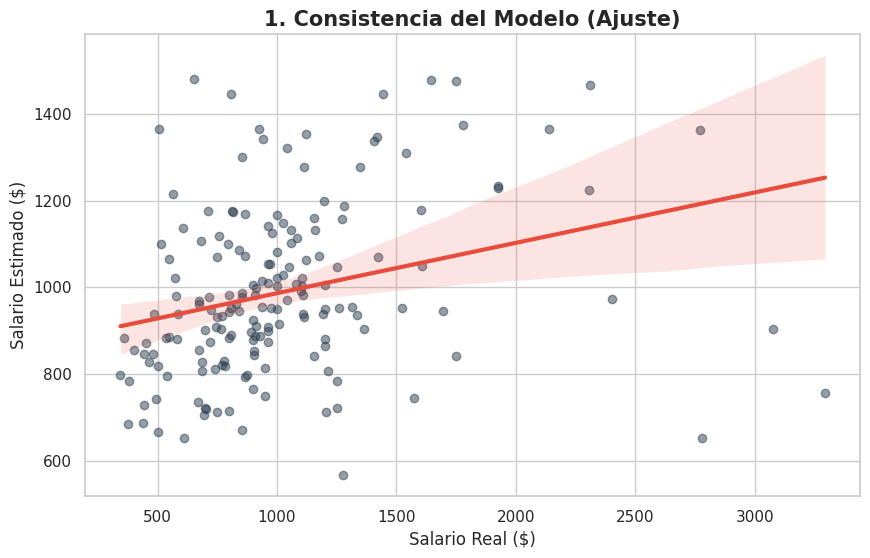

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))

sns.regplot(x=y_test, y=y_pred,
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'},
            line_kws={'color':'#e74c3c', 'lw':3})

plt.title('1. Consistencia del Modelo (Ajuste)', fontsize=15, fontweight='bold')
plt.xlabel('Salario Real ($)', fontsize=12)
plt.ylabel('Salario Estimado ($)', fontsize=12)
plt.show()

## 2. Diagnóstico de Errores (Residuales)

* En la segunda imagen, vemos el diagnostico de valores residuales, es decir, la diferencia entre el valor real y el predicho. Podemos observar que la distribución es aleatoria y homogénea, asi vemos que el error se comporta como ruido aleatorio. Esto indica que el modelo ya extrajo la información relevante de los datos y que no presenta señales de sobreajuste.

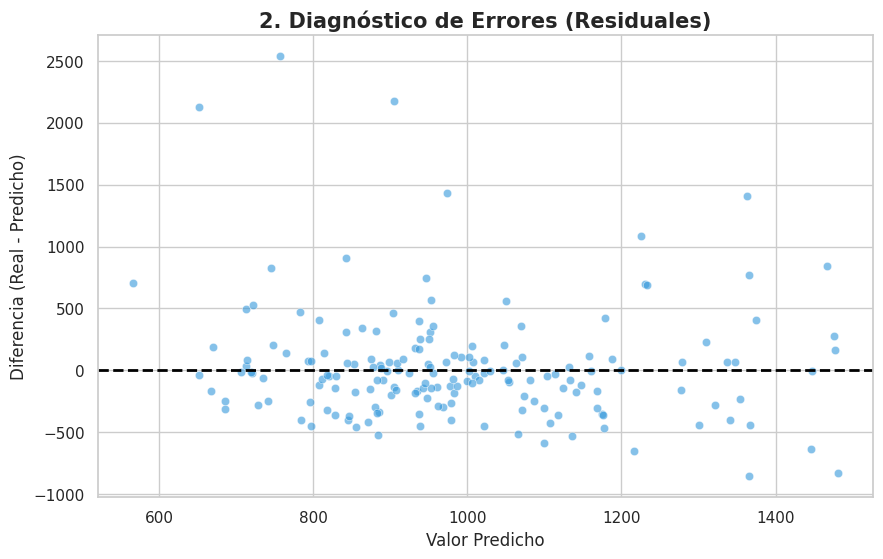

In [ ]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals, color='#3498db', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', lw=2)

plt.title('2. Diagnóstico de Errores (Residuales)', fontsize=15, fontweight='bold')
plt.xlabel('Valor Predicho', fontsize=12)
plt.ylabel('Diferencia (Real - Predicho)', fontsize=12)
plt.show()

## 3. Top 10 Variables más Influyentes

* Este analisis muestra las 10 variables que mas influyen dentro del modelo, este analisis se basa en la importancia de atributos calculada por Random Forest que está incluido en el ensamble, estadisticamente nos muestra còmo aporta cada variable a reducir la incertidumble de la predicciòn. Vemos que las variables que aparecen en los primeros lugares del modelo son las que nos permiten identificar los salarios entre altos y bajos ademàs de los años de educaciòn, capacidad cognitiva y experiencia.

/tmp/ipython-input-807/3652948212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


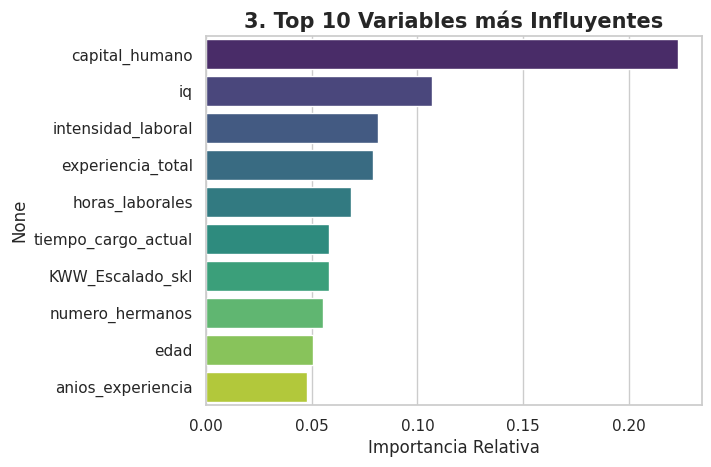

In [ ]:
rf_internal = stacking_model.estimators_[0]
importances = pd.Series(rf_internal.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

sns.barplot(x=importances.values, y=importances.index, palette='viridis')

plt.title('3. Top 10 Variables más Influyentes', fontsize=15, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.show()

## 4. Densidad de Probabilidad del Error

* En esta ultima imagen vemos la probabilidad de los errores mediante una curva suavizada. Lo ideal es que esta distribución sea simétrica y esté centrada en cero. Cuando el pico de la curva se encuentra en ese punto, se dice que el modelo es insesgado, es decir, que no tiende sistematicamente a sobreestimar ni a subestimar los salarios. Además, la amplitud de la curva refleja el margen de error: cuanto más concentrada esté, mayor será la precisión. El hecho de que la distribución se asemeje a una forma normal indica que el comportamiento del error es estable y estadísticamente consistente.

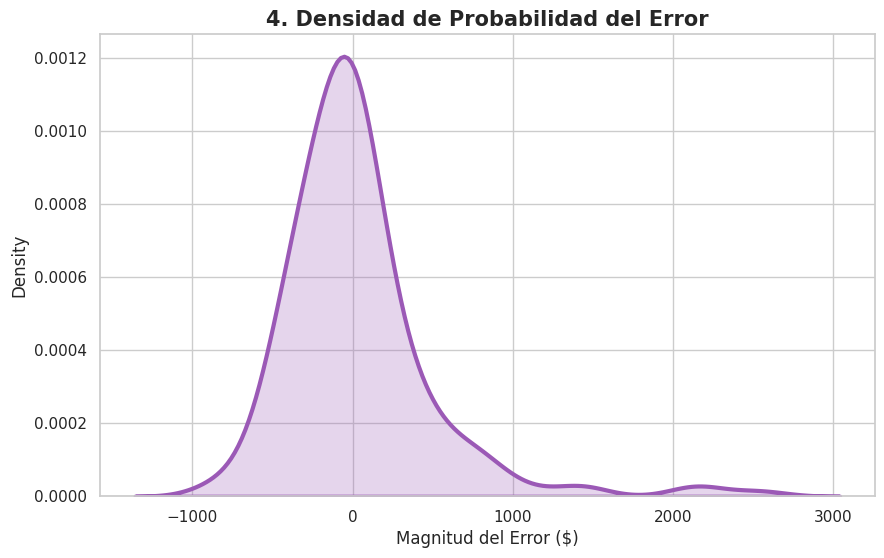

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(residuals, fill=True, color='#9b59b6', lw=3)

plt.title('4. Densidad de Probabilidad del Error', fontsize=15, fontweight='bold')
plt.xlabel('Magnitud del Error ($)', fontsize=12)
plt.show()

In [ ]:
print(f"Estadisticas finales")

print(f"R² (Varianza explicada): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Error promedio en $): ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE (Penalización de errores grandes): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


Estadisticas finales
R² (Varianza explicada): 0.0669
MAE (Error promedio en $): $296.03
RMSE (Penalización de errores grandes): 468.40
